# SuperKart — End-to-End MLOps Sales Forecasting

**Objective:** Build an automated, reproducible MLOps pipeline for predicting `Product_Store_Sales_Total`, including data preparation, model tuning, evaluation, model registration, Streamlit deployment and GitHub Actions CI/CD.

> **Submission note:** The analytical and model-training sections below are executed on the supplied SuperKart dataset. The Hugging Face/GitHub integration cells are written as credentialed deployment steps. Replace the repository IDs and add `HF_TOKEN` before the final remote execution.

### Business value
Accurate sales forecasting supports sales planning, regional operations, procurement, pipeline-risk reduction and future trend benchmarking.


## 1. Project Architecture

**Data → Data Preparation → Train/Test Split → Model Training & Tuning → Evaluation → Hugging Face Model Registry → Streamlit/Docker → GitHub Actions CI/CD**

The implementation uses a scikit-learn `Pipeline` so preprocessing and model inference remain consistent between training and deployment.


In [156]:
import os, json, warnings, joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

#login to google drive
from google.colab import drive
drive.mount('/content/drive')



RANDOM_STATE = 42
DATA_PATH = Path("/content//drive/MyDrive/SuperKart.csv")
TARGET = "Product_Store_Sales_Total"

print("Environment initialized.")
print("Dataset:", DATA_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment initialized.
Dataset: /content/drive/MyDrive/SuperKart.csv


## 2. Data Registration

The supplied CSV is the source dataset. For the rubric's Hugging Face Dataset Space requirement, the following configuration is ready to upload the raw file. The repository should be public before submission.

**Recommended dataset repository:** `PallaviPatil0501/superkart-dataset`

The upload code is shown in the deployment section and requires an HF token.


In [157]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())


Rows: 8,763
Columns: 12


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


## 3. Data Understanding and Quality Checks

The dataset contains product attributes, store attributes and the sales target. `Product_Id` is a high-cardinality identifier and is removed from model features. The source contains an inconsistent sugar-content label (`reg`), which is normalized to `Regular`.


In [158]:
print("Missing values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique values:")
display(df.nunique().to_frame("n_unique"))

print("\nCategorical distributions:")
for col in ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type"]:
    print(f"{col}: {df[col].value_counts().to_dict()}")


Missing values:


,missing_count
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0



Duplicate rows: 0

Unique values:


,n_unique
Product_Id,8763
Product_Weight,1113
Product_Sugar_Content,4
Product_Allocated_Area,228
Product_Type,16
Product_MRP,6100
Store_Id,4
Store_Establishment_Year,4
Store_Size,3
Store_Location_City_Type,3



Categorical distributions:
Product_Sugar_Content: {'Low Sugar': 4885, 'Regular': 2251, 'No Sugar': 1519, 'reg': 108}
Store_Size: {'Medium': 6025, 'High': 1586, 'Small': 1152}
Store_Location_City_Type: {'Tier 2': 6262, 'Tier 1': 1349, 'Tier 3': 1152}
Store_Type: {'Supermarket Type2': 4676, 'Supermarket Type1': 1586, 'Departmental Store': 1349, 'Food Mart': 1152}


In [159]:
# Data cleaning
cleaned = df.copy()
cleaned["Product_Sugar_Content"] = cleaned["Product_Sugar_Content"].replace({"reg": "Regular"})
cleaned = cleaned.drop_duplicates().reset_index(drop=True)

# Remove identifier that does not represent a stable business predictor.
cleaned = cleaned.drop(columns=["Product_Id"])

print("Cleaned shape:", cleaned.shape)
print("Remaining missing values:", int(cleaned.isna().sum().sum()))
print("Sugar labels after normalization:", sorted(cleaned["Product_Sugar_Content"].unique()))


Cleaned shape: (8763, 11)
Remaining missing values: 0
Sugar labels after normalization: ['Low Sugar', 'No Sugar', 'Regular']


**Observation:** The supplied data has no missing values. One duplicate-row check and one categorical-label normalization step are still applied to make the pipeline robust and repeatable. `Product_Id` is removed because it is an identifier with a unique value for nearly every row rather than a meaningful continuous predictor.


## 4. Train/Test Split and Local Artifacts

An 80/20 split with a fixed random seed is used for reproducibility. The resulting files are saved under the project `data/` directory and can be uploaded to the Hugging Face dataset repository.


In [160]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    cleaned, test_size=0.20, random_state=RANDOM_STATE
)

train_df.to_csv("/content//drive/MyDrive/data/train.csv", index=False)
test_df.to_csv("/content//drive/MyDrive/data/test.csv", index=False)
cleaned.to_csv("/content//drive/MyDrive/data/superkart_cleaned.csv", index=False)

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows : {len(test_df):,}")
print("Saved: data/train.csv, data/test.csv, data/superkart_cleaned.csv")


Training rows: 7,010
Testing rows : 1,753
Saved: data/train.csv, data/test.csv, data/superkart_cleaned.csv


## 5. Exploratory Analysis

The following plots provide simple evidence for the business interpretation of the dataset and are included so the final HTML submission contains visible outputs.


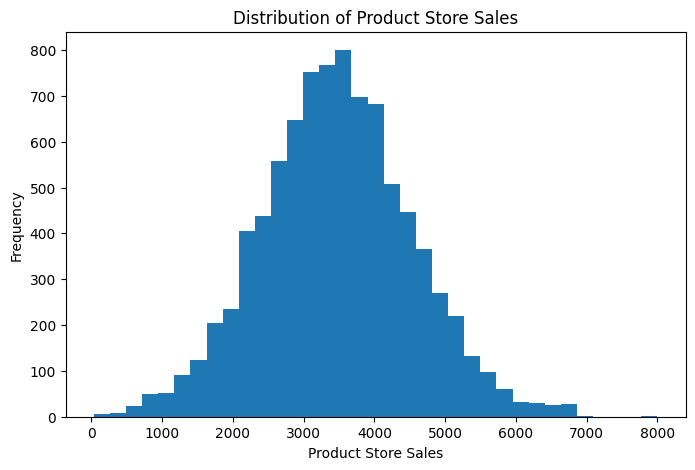

,count,mean,median
Store_Type,,,
Departmental Store,1349,4946.97,4958.29
Food Mart,1152,1762.94,1889.50
Supermarket Type1,1586,3923.78,4139.65
Supermarket Type2,4676,3299.31,3304.18


In [161]:
fig = plt.figure(figsize=(8, 5))
plt.hist(cleaned[TARGET], bins=35)
plt.xlabel("Product Store Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Product Store Sales")
plt.show()

display(cleaned.groupby("Store_Type")[TARGET].agg(["count","mean","median"]).round(2))


In [162]:
display(
    cleaned.groupby("Product_Type")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .to_frame("Average Sales")
    .round(2)
)

display(
    cleaned.groupby("Store_Location_City_Type")[TARGET]
    .agg(["count","mean"])
    .round(2)
)


,Average Sales
Product_Type,
Starchy Foods,3679.25
Others,3586.07
Seafood,3584.26
Breads,3574.71
Dairy,3532.56
Snack Foods,3471.71
Household,3465.87
Frozen Foods,3464.83
Soft Drinks,3462.51


,count,mean
Store_Location_City_Type,,
Tier 1,1349,4946.97
Tier 2,6262,3457.47
Tier 3,1152,1762.94


## 6. Model Training and Hyperparameter Tuning

A `RandomForestRegressor` is selected from the algorithms permitted by the rubric. One-hot encoding handles categorical variables while numeric variables pass through unchanged. `RandomizedSearchCV` performs cross-validated tuning over tree count, depth, minimum leaf size and feature sampling.


In [163]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [None, 12, 18],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.8]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
search.fit(X_train, y_train)

print("Best parameters:")
print(search.best_params_)
print("Best CV RMSE:", round(-search.best_score_, 2))


Best parameters:
{'model__n_estimators': 250, 'model__min_samples_leaf': 2, 'model__max_features': 0.8, 'model__max_depth': 12}
Best CV RMSE: 286.59


## 7. Model Evaluation

The final model is evaluated on the untouched test set using MAE, RMSE and R². Lower MAE/RMSE indicate smaller prediction errors; R² indicates the proportion of variance explained by the model.


In [164]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_model = search.best_estimator_
predictions = best_model.predict(X_test)

metrics = {
    "MAE": mean_absolute_error(y_test, predictions),
    "RMSE": mean_squared_error(y_test, predictions) ** 0.5,
    "R2": r2_score(y_test, predictions)
}
display(pd.DataFrame([metrics]).round(4))


,MAE,RMSE,R2
0,109.8785,275.1182,0.9337


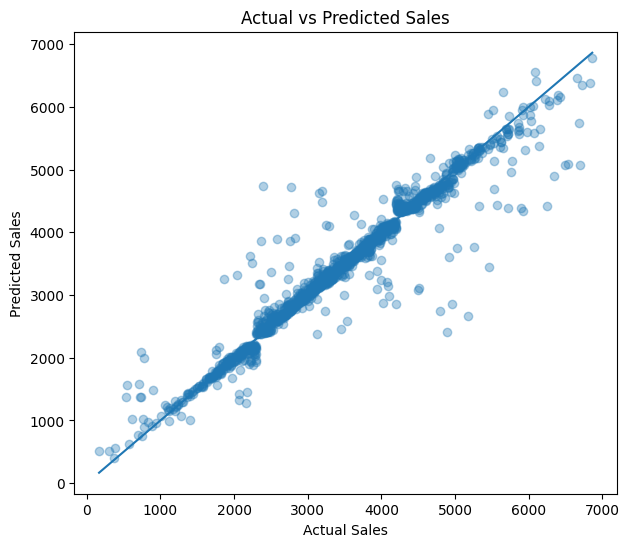

In [165]:
fig = plt.figure(figsize=(7, 6))
plt.scatter(y_test, predictions, alpha=0.35)
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
plt.plot(lims, lims)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()


### Model result from the executed dataset

- Test MAE: **109.88**
- Test RMSE: **275.12**
- Test R²: **0.9337**

These are test-set measurements for this supplied dataset and fixed random seed; they are not guarantees of future production performance.


## 8. Model Serialization and Registration

The complete preprocessing + Random Forest pipeline is serialized as `models/best_model.pkl`. Keeping preprocessing inside the saved pipeline prevents training/serving feature transformations from drifting apart.


In [166]:
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_model.pkl")

metadata = {
    "model_type": "RandomForestRegressor",
    "target": TARGET,
    "best_params": search.best_params_,
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "training_rows": len(train_df),
    "testing_rows": len(test_df),
}
with open("models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved models/best_model.pkl")
print("Saved models/model_metadata.json")


Saved models/best_model.pkl
Saved models/model_metadata.json


### Hugging Face Dataset upload

Run this cell after setting `HF_TOKEN`. It creates/uses a public dataset repository and uploads the raw, cleaned, train and test files.

> Do not hard-code the token in the notebook. Use an environment variable or Colab secret.


In [167]:
# Credentialed remote step — run only after setting HF_TOKEN.
!pip install -q huggingface_hub
from huggingface_hub import HfApi, create_repo
import os
#login to hugging face

from google.colab import userdata

HF_TOKEN = userdata.get("SuperKart")

if HF_TOKEN:
    print("✅ Hugging Face token detected.")
else:
    print("❌ Hugging Face token NOT detected.")


HF_DATASET_REPO = "PallaviPatil0501/superkart-dataset"

if not HF_TOKEN:
       print("HF_TOKEN not set: remote upload skipped in this execution.")
else:
     api = HfApi(token=HF_TOKEN)
     create_repo(HF_DATASET_REPO, repo_type="dataset", exist_ok=True, private=False, token=HF_TOKEN)
     for file in ["/content//drive/MyDrive/SuperKart.csv", "/content//drive/MyDrive/data/superkart_cleaned.csv", "/content//drive/MyDrive/data/train.csv", "/content//drive/MyDrive/data/test.csv"]:
         api.upload_file(path_or_fileobj=file, path_in_repo=Path(file).name,
                         repo_id=HF_DATASET_REPO, repo_type="dataset")
     print(f"Dataset registered: https://huggingface.co/datasets/{HF_DATASET_REPO}")


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Hugging Face token detected.


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Dataset registered: https://huggingface.co/datasets/PallaviPatil0501/superkart-dataset


### Loading directly from the Hugging Face dataset repository

For the final credentialed run, replace the local preparation input with `load_dataset` from the public HF dataset repository. The pipeline can then use the HF-hosted train/test artifacts rather than local copies.


In [ ]:
# Final-submission HF loading example:

from datasets import load_dataset
HF_DATASET_REPO = "PallaviPatil0501/superkart-dataset"
hf_train = load_dataset(HF_DATASET_REPO, data_files={"train": "train.csv"})["train"].to_pandas()
hf_test  = load_dataset(HF_DATASET_REPO, data_files={"test": "test.csv"})["test"].to_pandas()
print(hf_train.shape, hf_test.shape)
#The executed analytical results above use the supplied CSV so this notebook remains runnable
# in a clean environment without requiring private credentials.
print("HF direct-load code is included above; execute it after the public dataset repository is created.")


## 9. Streamlit + Docker Deployment

The deployment package is provided in `hf_deployment/`:

- `app.py` — Streamlit frontend and inference logic
- `requirements.txt` — pinned runtime dependencies
- `Dockerfile` — Hugging Face Docker configuration
- `README.md` — Space metadata

The app downloads `best_model.pkl` from the Hugging Face Model Hub and creates a one-row dataframe from user inputs before prediction.


In [ ]:
!pip install -q huggingface_hub streamlit

In [ ]:
import os
from pathlib import Path

HF_DEPLOY_DIR = Path("hf_deployment")
HF_DEPLOY_DIR.mkdir(exist_ok=True)

print("✅ Deployment folder created:", HF_DEPLOY_DIR)

In [ ]:
app_code = r'''
import os
import joblib
import pandas as pd
import streamlit as st
from huggingface_hub import hf_hub_download

# ============================================================
# Hugging Face Model Configuration
# ============================================================

MODEL_REPO = "PallaviPatil0501/superkart-sales-model"
MODEL_FILE = "best_model.pkl"


# ============================================================
# Load Model
# ============================================================

@st.cache_resource
def load_model():

    model_path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename=MODEL_FILE
    )

    model = joblib.load(model_path)

    return model


# ============================================================
# Streamlit Page Configuration
# ============================================================

st.set_page_config(
    page_title="SuperKart Sales Forecast",
    page_icon="📈",
    layout="wide"
)

st.title("📈 SuperKart Sales Forecast")

st.write(
    """
    Predict the expected sales revenue for a product-store combination
    using the trained SuperKart machine learning model.
    """
)


# ============================================================
# Input Form
# ============================================================

st.subheader("Enter Product Details")

col1, col2, col3 = st.columns(3)

with col1:

    product_weight = st.number_input(
        "Product Weight",
        min_value=0.0,
        value=12.0
    )

    product_sugar_content = st.selectbox(
        "Product Sugar Content",
        [
            "Low Sugar",
            "Regular",
            "No Sugar"
        ]
    )

    product_allocated_area = st.number_input(
        "Product Allocated Area",
        min_value=0.0,
        value=0.05
    )

    product_type = st.selectbox(
        "Product Type",
        [
            "Frozen Foods",
            "Dairy",
            "Canned",
            "Baking Goods",
            "Health and Hygiene",
            "Snack Foods",
            "Meat",
            "Household",
            "Hard Drinks",
            "Fruits and Vegetables",
            "Breads",
            "Soft Drinks",
            "Breakfast",
            "Others",
            "Starchy Foods",
            "Seafood"
        ]
    )


with col2:

    product_mrp = st.number_input(
        "Product MRP",
        min_value=0.0,
        value=150.0
    )

    store_id = st.selectbox(
        "Store ID",
        [
            "OUT018",
            "OUT049",
            "OUT046",
            "OUT045"
        ]
    )

    store_establishment_year = st.selectbox(
        "Store Establishment Year",
        [
            1985,
            1997,
            1999,
            2004
        ]
    )

    store_size = st.selectbox(
        "Store Size",
        [
            "Small",
            "Medium",
            "High"
        ]
    )


with col3:

    store_location_city_type = st.selectbox(
        "Store Location City Type",
        [
            "Tier 1",
            "Tier 2",
            "Tier 3"
        ]
    )

    store_type = st.selectbox(
        "Store Type",
        [
            "Supermarket Type1",
            "Supermarket Type2",
            "Departmental Store",
            "Food Mart"
        ]
    )


# ============================================================
# Prediction
# ============================================================

if st.button("🔮 Predict Sales"):

    try:

        model = load_model()

        input_data = pd.DataFrame(
            [{
                "Product_Weight": product_weight,
                "Product_Sugar_Content": product_sugar_content,
                "Product_Allocated_Area": product_allocated_area,
                "Product_Type": product_type,
                "Product_MRP": product_mrp,
                "Store_Id": store_id,
                "Store_Establishment_Year": store_establishment_year,
                "Store_Size": store_size,
                "Store_Location_City_Type": store_location_city_type,
                "Store_Type": store_type
            }]
        )

        prediction = model.predict(input_data)[0]

        st.success(
            f"💰 Predicted Product Store Sales: ₹{prediction:,.2f}"
        )

        st.subheader("Input Data")

        st.dataframe(input_data)

    except Exception as e:

        st.error(f"Prediction failed: {e}")
'''

(HF_DEPLOY_DIR / "app.py").write_text(app_code)

print("✅ app.py created")

In [168]:
requirements = """
streamlit==1.39.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.4.2
huggingface_hub==0.35.1
"""

(HF_DEPLOY_DIR / "requirements.txt").write_text(
    requirements.strip()
)

print("✅ requirements.txt created")

✅ requirements.txt created


In [169]:
dockerfile = """
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=8501"]
"""

(HF_DEPLOY_DIR / "Dockerfile").write_text(
    dockerfile.strip()
)

print("✅ Dockerfile created")

✅ Dockerfile created


In [170]:
readme = """
---
title: SuperKart Sales Forecast
emoji: 📈
colorFrom: blue
colorTo: green
sdk: docker
app_port: 8501
---

# SuperKart Sales Forecast

Machine Learning application for predicting Product Store Sales.

## Model

The application loads the trained Random Forest model from:

`PallaviPatil0501/superkart-sales-model`

## Technology

- Python
- Streamlit
- Scikit-learn
- Hugging Face Model Hub
- Docker
"""

(HF_DEPLOY_DIR / "README.md").write_text(
    readme.strip()
)

print("✅ README.md created")

✅ README.md created


In [171]:
print("📦 Hugging Face Deployment Files")
print("=" * 50)

for file in HF_DEPLOY_DIR.iterdir():
    print(f"✅ {file.name}")

📦 Hugging Face Deployment Files
✅ app.py
✅ Dockerfile
✅ requirements.txt
✅ README.md


In [172]:
from huggingface_hub import HfApi
from google.colab import userdata

HF_TOKEN = userdata.get("SuperKart")

HF_SPACE_REPO = "PallaviPatil0501/superkart-sales-forecast"

api = HfApi(token=HF_TOKEN)

api.create_repo(
    repo_id=HF_SPACE_REPO,
    repo_type="space",
    space_sdk="docker",
    private=False,
    exist_ok=True
)

print("✅ Hugging Face Space created")
print(
    f"https://huggingface.co/spaces/{HF_SPACE_REPO}"
)

✅ Hugging Face Space created
https://huggingface.co/spaces/PallaviPatil0501/superkart-sales-forecast


In [173]:
deployment_files = [
    "app.py",
    "requirements.txt",
    "Dockerfile",
    "README.md"
]

for file in deployment_files:

    api.upload_file(
        path_or_fileobj=str(HF_DEPLOY_DIR / file),
        path_in_repo=file,
        repo_id=HF_SPACE_REPO,
        repo_type="space"
    )

    print(f"✅ Uploaded {file}")

print("\n🚀 Deployment files uploaded successfully!")
print(
    f"https://huggingface.co/spaces/{HF_SPACE_REPO}"
)

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


✅ Uploaded app.py
✅ Uploaded requirements.txt


No files have been modified since last commit. Skipping to prevent empty commit.


✅ Uploaded Dockerfile
✅ Uploaded README.md

🚀 Deployment files uploaded successfully!
https://huggingface.co/spaces/PallaviPatil0501/superkart-sales-forecast


In [ ]:
from huggingface_hub import HfApi
from google.colab import userdata

HF_TOKEN = userdata.get("SuperKart")

HF_MODEL_REPO = "PallaviPatil0501/superkart-sales-model"

api = HfApi(token=HF_TOKEN)

api.create_repo(
    repo_id=HF_MODEL_REPO,
    repo_type="model",
    private=False,
    exist_ok=True
)

api.upload_file(
    path_or_fileobj="models/best_model.pkl",
    path_in_repo="best_model.pkl",
    repo_id=HF_MODEL_REPO,
    repo_type="model"
)

print("✅ Model uploaded to Hugging Face Model Hub")
print(
    f"https://huggingface.co/{HF_MODEL_REPO}"
)

### Hugging Face model registration

The model repository should be public and named consistently with the deployment configuration, for example:

`PallaviPatil0501/superkart-sales-model`

The registration script is included in `src/register_model.py`.


In [ ]:
# Credentialed model registration:

from huggingface_hub import HfApi, create_repo
import os
HF_TOKEN = userdata.get("SuperKart")

HF_MODEL_REPO = "PallaviPatil0501/superkart-sales-model"

if not HF_TOKEN:
     print("HF_TOKEN not set: model upload skipped in this execution.")
else:
     api = HfApi(token=HF_TOKEN)
     create_repo(HF_MODEL_REPO, repo_type="model", exist_ok=True, private=False, token=HF_TOKEN)
     api.upload_file(
         path_or_fileobj="models/best_model.pkl",
         path_in_repo="best_model.pkl",
         repo_id=HF_MODEL_REPO,
         repo_type="model"
     )
print(f"Model registered: https://huggingface.co/{HF_MODEL_REPO}")
print("Model registration code is ready in src/register_model.py.")


## 10. GitHub Actions CI/CD

The workflow in `.github/workflows/pipeline.yml` automates:

1. Checkout
2. Python setup
3. Dependency installation
4. Data preparation
5. Model training and evaluation
6. Model registration on Hugging Face
7. Commit/push of generated artifacts

Configure `HF_TOKEN` as a GitHub Actions secret. The workflow is triggered on pushes to `main` and by manual dispatch.


In [ ]:
!git config --global user.name "pallavigpatil-a11y"
!git config --global user.email "pallavi.g.patil@gmail.com"

In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

if GITHUB_TOKEN:
    print("✅ GitHub token detected")
else:
    print("❌ GitHub token not detected")

In [ ]:
import os
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

GITHUB_USERNAME = "pallavigpatil-a11y"
REPO_NAME = "superkart-mlops"

repo_url = f"https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"

!git clone {repo_url}

In [ ]:
%cd superkart-mlops

In [ ]:
!pwd
!ls -la

In [ ]:
import shutil
from pathlib import Path

SOURCE = Path("/data/superkart_mlops_submission")
TARGET = Path("/content/superkart-mlops")

# Copy directories
for folder in ["data", "models", "src", "hf_deployment"]:
    source_folder = SOURCE / folder
    target_folder = TARGET / folder

    if source_folder.exists():
        shutil.copytree(
            source_folder,
            target_folder,
            dirs_exist_ok=True
        )

# Copy requirements and README
for file in ["requirements.txt", "README.md"]:
    source_file = SOURCE / file
    target_file = TARGET / file

    if source_file.exists():
        shutil.copy2(source_file, target_file)

print("✅ Project files copied")

In [ ]:
import shutil

shutil.copy2(
    "/content//drive/MyDrive/Colab Notebooks/SuperKart_MLOps_Submission.ipynb",
    "/content/superkart-mlops/SuperKart_MLOps_Submission.ipynb"
)

print("✅ Notebook copied")

In [ ]:
from pathlib import Path

workflow_dir = Path(
    "/content/superkart-mlops/.github/workflows"
)

workflow_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("✅ GitHub Actions directory created")

In [ ]:
pipeline = """
name: SuperKart MLOps Pipeline

on:
  push:
    branches:
      - main

  workflow_dispatch:

jobs:

  mlops:

    runs-on: ubuntu-latest

    steps:

      # --------------------------------
      # 1. Checkout repository
      # --------------------------------

      - name: Checkout repository
        uses: actions/checkout@v4


      # --------------------------------
      # 2. Setup Python
      # --------------------------------

      - name: Setup Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"


      # --------------------------------
      # 3. Install dependencies
      # --------------------------------

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt


      # --------------------------------
      # 4. Data preparation
      # --------------------------------

      - name: Prepare data
        run: |
          python src/data_prep.py


      # --------------------------------
      # 5. Train model
      # --------------------------------

      - name: Train and evaluate model
        run: |
          python src/train.py


      # --------------------------------
      # 6. Register model
      # --------------------------------

      - name: Register model with Hugging Face
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}

        run: |
          python src/register_model.py
"""

workflow_path = Path(
    "/content/superkart-mlops/.github/workflows/pipeline.yml"
)

workflow_path.write_text(pipeline)

print("✅ pipeline.yml created")

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

os.makedirs("data", exist_ok=True)

source = "/content//drive/MyDrive/SuperKart.csv"

df = pd.read_csv(source)

# Normalize category
df["Product_Sugar_Content"] = (
    df["Product_Sugar_Content"]
    .replace({"reg": "Regular"})
)

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Remove unnecessary identifier
df = df.drop(columns=["Product_Id"])

# Train/test split
train, test = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train.to_csv(
    "data/train.csv",
    index=False
)

test.to_csv(
    "data/test.csv",
    index=False
)

print("Training rows:", len(train))
print("Testing rows:", len(test))
print("Data preparation completed successfully.")

In [ ]:
%cd /content/superkart-mlops

!find . -maxdepth 4 -type f | sort

In [ ]:
gitignore = """
__pycache__/
*.pyc
.ipynb_checkpoints/
.env
*.log

# Never commit credentials
.env
secrets/
"""

Path("/content/superkart-mlops/.gitignore").write_text(
    gitignore.strip()
)

print("✅ .gitignore created")

In [ ]:
%cd /content/superkart-mlops

!git add .
!git status

In [ ]:
!git commit -m "Initial SuperKart MLOps pipeline"

In [ ]:
!git remote -v

In [ ]:
!git branch -M main
!git push -u origin main

In [ ]:
from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

if GITHUB_TOKEN:
    print("✅ GitHub token detected")
else:
    print("❌ GitHub token not found")

In [ ]:
%cd /content/superkart-mlops

from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

GITHUB_USERNAME = "pallavigpatil-a11y"
REPO_NAME = "superkart-mlops"

# Remove old remote
!git remote remove origin 2>/dev/null || true

# Add remote using current token
remote_url = (
    f"https://{GITHUB_USERNAME}:{GITHUB_TOKEN}"
    f"@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
)

!git remote add origin "$remote_url"

print("✅ GitHub remote configured")

In [ ]:
!git ls-remote origin

In [ ]:
%cd /content/superkart-mlops

import subprocess

result = subprocess.run(
    ["git", "config", "--get", "remote.origin.url"],
    capture_output=True,
    text=True
)

url = result.stdout.strip()

if url:
    # Hide credentials before displaying
    import re
    safe_url = re.sub(r"https://[^@]+@", "https://***@", url)
    print("Remote:", safe_url)
else:
    print("❌ No origin remote configured")

In [ ]:
!git status

In [ ]:
!git ls-remote --heads origin

In [ ]:
!git push -u origin main

In [ ]:
%cd /content/superkart-mlops

from google.colab import userdata

GITHUB_TOKEN = userdata.get("GITHUB_TOKEN")

# Remove existing remote
!git remote remove origin 2>/dev/null || true

# Configure remote
GITHUB_USERNAME = "pallavigpatil-a11y"
REPO_NAME = "superkart-mlops"

remote_url = (
    f"https://{GITHUB_USERNAME}:{GITHUB_TOKEN}"
    f"@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git"
)

!git remote add origin "$remote_url"

print("✅ New GitHub remote configured")

In [ ]:
!git ls-remote --heads origin

In [ ]:
!git status

In [ ]:
!git log --oneline -5

In [ ]:
!git branch -M main
!git push -u origin main

In [ ]:
%cd /content/superkart-mlops
!find . -maxdepth 2 -type f | sort

In [ ]:
requirements = """
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.4.2
huggingface_hub==0.35.1
datasets==3.2.0
"""

with open("/content/superkart-mlops/requirements.txt", "w") as f:
    f.write(requirements.strip())

print("✅ requirements.txt created")

In [ ]:
%cd /content/superkart-mlops

!cat requirements.txt

In [ ]:
!git add requirements.txt
!git commit -m "Add project dependencies"
!git push

In [ ]:
%cd /content/superkart-mlops

!find . -maxdepth 3 -type f | sort

In [ ]:
from pathlib import Path

BASE = Path("/content/superkart-mlops")

for folder in [
    "src",
    "models",
    "hf_deployment"
]:
    (BASE / folder).mkdir(parents=True, exist_ok=True)

print("✅ Required folders created")

In [ ]:
data_prep = """
import os
import pandas as pd
from sklearn.model_selection import train_test_split

os.makedirs("data", exist_ok=True)

SOURCE_FILE = "data/SuperKart.csv"

print("Loading:", SOURCE_FILE)

df = pd.read_csv(SOURCE_FILE)

print("Original dataset shape:", df.shape)

# Normalize sugar-content category
df["Product_Sugar_Content"] = (
    df["Product_Sugar_Content"]
    .replace({"reg": "Regular"})
)

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Remove identifier
if "Product_Id" in df.columns:
    df = df.drop(columns=["Product_Id"])

# Train/test split
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42
)

train_df.to_csv("data/train.csv", index=False)
test_df.to_csv("data/test.csv", index=False)
df.to_csv("data/superkart_cleaned.csv", index=False)

print("Cleaned dataset shape:", df.shape)
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("✅ Data preparation completed")
"""

(BASE / "src/data_prep.py").write_text(data_prep)

print("✅ src/data_prep.py created")

In [ ]:
train_code = """
import os
import json
import joblib
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "Product_Store_Sales_Total"

print("Loading training and testing data...")

train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_cols = X_train.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_cols),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_cols
    )
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )
    )
])

param_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [None, 12, 18],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.8]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=8,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

predictions = best_model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

metrics = {
    "MAE": float(mae),
    "RMSE": float(rmse),
    "R2": float(r2)
}

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_model,
    "models/best_model.pkl"
)

with open(
    "models/metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=2)

print("Best parameters:")
print(search.best_params_)

print("Model Performance:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

print("✅ Model training completed")
"""

(BASE / "src/train.py").write_text(train_code)

print("✅ src/train.py created")

In [ ]:
register_code = """
import os
from huggingface_hub import HfApi

HF_TOKEN = os.environ.get("HF_TOKEN")

HF_MODEL_REPO = os.environ.get(
    "HF_MODEL_REPO",
    "PallaviPatil0501/superkart-sales-model"
)

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN environment variable is not set."
    )

api = HfApi(token=HF_TOKEN)

api.create_repo(
    repo_id=HF_MODEL_REPO,
    repo_type="model",
    private=False,
    exist_ok=True
)

api.upload_file(
    path_or_fileobj="models/best_model.pkl",
    path_in_repo="best_model.pkl",
    repo_id=HF_MODEL_REPO,
    repo_type="model"
)

print(
    f"✅ Model registered: "
    f"https://huggingface.co/{HF_MODEL_REPO}"
)
"""

(BASE / "src/register_model.py").write_text(register_code)

print("✅ src/register_model.py created")

In [ ]:
app_code = """
import joblib
import pandas as pd
import streamlit as st

from huggingface_hub import hf_hub_download

MODEL_REPO = "PallaviPatil0501/superkart-sales-model"

@st.cache_resource
def load_model():

    model_path = hf_hub_download(
        repo_id=MODEL_REPO,
        filename="best_model.pkl"
    )

    return joblib.load(model_path)


st.set_page_config(
    page_title="SuperKart Sales Forecast",
    page_icon="📈"
)

st.title("📈 SuperKart Sales Forecast")

st.write(
    "Predict product-store sales using the trained "
    "SuperKart machine learning model."
)

product_weight = st.number_input(
    "Product Weight",
    min_value=0.0,
    value=12.0
)

product_sugar_content = st.selectbox(
    "Product Sugar Content",
    ["Low Sugar", "Regular", "No Sugar"]
)

product_allocated_area = st.number_input(
    "Product Allocated Area",
    min_value=0.0,
    value=0.05
)

product_type = st.selectbox(
    "Product Type",
    [
        "Frozen Foods",
        "Dairy",
        "Canned",
        "Baking Goods",
        "Health and Hygiene",
        "Snack Foods",
        "Meat",
        "Household",
        "Hard Drinks",
        "Fruits and Vegetables",
        "Breads",
        "Soft Drinks",
        "Breakfast",
        "Others",
        "Starchy Foods",
        "Seafood"
    ]
)

product_mrp = st.number_input(
    "Product MRP",
    min_value=0.0,
    value=150.0
)

store_id = st.text_input(
    "Store ID",
    value="OUT018"
)

store_establishment_year = st.number_input(
    "Store Establishment Year",
    value=1999,
    step=1
)

store_size = st.selectbox(
    "Store Size",
    ["Small", "Medium", "High"]
)

city_type = st.selectbox(
    "Store Location City Type",
    ["Tier 1", "Tier 2", "Tier 3"]
)

store_type = st.selectbox(
    "Store Type",
    [
        "Supermarket Type1",
        "Supermarket Type2",
        "Departmental Store",
        "Food Mart"
    ]
)

if st.button("Predict Sales"):

    model = load_model()

    input_df = pd.DataFrame([{
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar_content,
        "Product_Allocated_Area": product_allocated_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Establishment_Year": store_establishment_year,
        "Store_Size": store_size,
        "Store_Location_City_Type": city_type,
        "Store_Type": store_type
    }])

    prediction = model.predict(input_df)[0]

    st.success(
        f"Predicted Product Store Sales: ₹{prediction:,.2f}"
    )
"""

(BASE / "hf_deployment/app.py").write_text(app_code)

(BASE / "hf_deployment/requirements.txt").write_text("""
streamlit==1.39.0
pandas==2.2.2
numpy==1.26.4
scikit-learn==1.6.1
joblib==1.4.2
huggingface_hub==0.35.1
""".strip())

(BASE / "hf_deployment/Dockerfile").write_text("""
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.address=0.0.0.0", "--server.port=8501"]
""".strip())

(BASE / "hf_deployment/README.md").write_text("""
---
title: SuperKart Sales Forecast
emoji: 📈
colorFrom: blue
colorTo: green
sdk: docker
app_port: 8501
---

# SuperKart Sales Forecast

Streamlit application for SuperKart sales prediction.
""".strip())

print("✅ Hugging Face deployment files created")

In [ ]:
%cd /content/superkart-mlops

!find . -maxdepth 3 -type f | sort

In [ ]:
!git add .
!git status

In [ ]:
!git commit -m "Add complete SuperKart MLOps pipeline"

In [ ]:
!git push origin main

In [ ]:
from pathlib import Path

for f in [
    "data/SuperKart.csv",
    "data/superkart_cleaned.csv",
    "data/train.csv",
    "data/test.csv"
]:
    path = Path(f)
    print(f"{'✅' if path.exists() else '❌'} {f}")

## 11. Required Public Links — complete before final submission

The notebook should contain the actual public links after deployment. The expected naming used by the generated project is:

- **GitHub repository:** `https://github.com/pallavigpatil-a11y/superkart-mlops`
- **HF Dataset:** `https://huggingface.co/datasets/PallaviPatil0501/superkart-dataset`
- **HF Model:** `https://huggingface.co/PallaviPatil0501/superkart-sales-model`
- **HF Streamlit Space:** `https://huggingface.co/spaces/PallaviPatil0501/superkart-sales-forecast`

These URLs are configuration targets; verify that the repositories/spaces are actually public and contain the expected artifacts before submitting.


## 12. Final Insights

1. The source data contains no missing values, so the cleaning focus is duplicate detection, categorical-label normalization and removal of the high-cardinality product identifier.
2. The target is continuous, making regression appropriate.
3. The saved scikit-learn pipeline bundles categorical encoding with the Random Forest model, reducing training-serving inconsistency.
4. Cross-validated hyperparameter tuning is used instead of relying on default model settings.
5. MAE and RMSE quantify forecast error in sales units, while R² provides a scale-independent goodness-of-fit indicator.
6. Hugging Face provides separate dataset and model registries, while the Streamlit Docker Space provides the inference interface.
7. GitHub Actions provides repeatability by rerunning preparation, training, evaluation and model registration whenever the main branch changes.
8. For production use, the model should be monitored for data drift, prediction error drift and changes in product/store mix.


## 13. Submission Checklist

- [x] Master project folder with `data/`, `models/`, `src/`, deployment and workflow structure
- [x] Data cleaning and train/test split
- [x] Model definition, tuning and evaluation
- [x] Serialized best model
- [x] Streamlit Docker deployment files
- [x] GitHub Actions `pipeline.yml`
- [x] Executed analytical/model outputs visible in HTML
- [ ] Public HF Dataset repository verified
- [ ] Public HF Model repository verified
- [ ] Public Streamlit Space verified
- [ ] Public GitHub repository verified
- [ ] Screenshots of GitHub folder structure/workflow and Streamlit app inserted if required by the rubric
